# Logistic Regression Demo: Gradient Descent, Wolfe Line Search, Newton's Method, and scikit-learn

In this notebook, we demonstrate how to solve **binary logistic regression** in a way parallel to the OLS notebook.

We will organize the notebook into four parts:

1. **fixed-step Gradient Descent**
2. **Gradient Descent + Wolfe line search**
3. **Newton's method**
4. **scikit-learn reference solution**

We also compare the methods through:

- estimated coefficients,
- prediction performance,
- decision boundaries,
- loss curves,
- parameter trajectories.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

np.random.seed(123)

## 1. Generate synthetic classification data

We generate two-dimensional data so that:

- the fitted classifier can be visualized in the plane,
- the parameter trajectory can be plotted in a two-dimensional coefficient subspace.

The true model is

$$
P(y=1 \mid x) = \sigma(\theta_0 + \theta_1 x_1 + \theta_2 x_2),
$$

where $\sigma(z) = 1 / (1 + e^{-z})$ is the sigmoid function.


In [2]:
n = 250
X = np.random.randn(n, 2)

theta_true = np.array([-0.3, 2.0, -1.5])   # intercept, coef1, coef2

def add_intercept(X):
    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    return np.hstack([np.ones((n, 1)), X])

def sigmoid(z):
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z)

    pos = z >= 0
    neg = ~pos

    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[neg])
    out[neg] = ez / (1.0 + ez)
    return out

X_i = add_intercept(X)
probs_true = sigmoid(X_i @ theta_true)
y = (np.random.rand(n) < probs_true).astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("True theta:", theta_true)
print("Positive rate:", y.mean())

X shape: (250, 2)
y shape: (250,)
True theta: [-0.3  2.  -1.5]
Positive rate: 0.432


## 2. Visualize the raw data

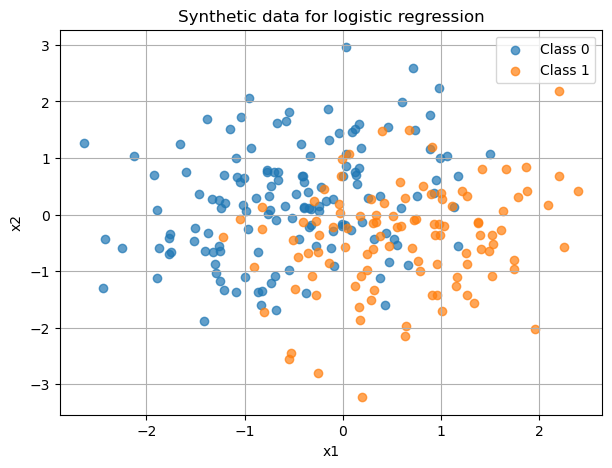

In [3]:
plt.figure(figsize=(7, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], alpha=0.7, label="Class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], alpha=0.7, label="Class 1")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Synthetic data for logistic regression")
plt.legend()
plt.grid(True)
plt.show()

## 3. Common utilities

We first define the logistic loss, its gradient, its Hessian, and several reusable plotting / prediction utilities.

For a parameter vector $\theta$, the empirical logistic loss is

$$
f(\theta)
=
-\frac{1}{n}
\sum_{i=1}^n
\left[
y_i \log p_i + (1-y_i) \log (1-p_i)
\right],
\qquad
p_i = \sigma(x_i^\top \theta).
$$


In [4]:
def logistic_loss(X, y, theta):
    z = X @ theta
    p = sigmoid(z)
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


def logistic_gradient(X, y, theta):
    n = X.shape[0]
    p = sigmoid(X @ theta)
    return (X.T @ (p - y)) / n


def logistic_hessian(X, theta):
    n = X.shape[0]
    p = sigmoid(X @ theta)
    w = p * (1 - p)
    return (X.T @ (X * w[:, None])) / n


def predict_proba_logistic(X, theta, fit_intercept=True):
    X = np.asarray(X, dtype=float)
    if fit_intercept:
        X = add_intercept(X)
    return sigmoid(X @ theta)


def predict_logistic(X, theta, fit_intercept=True, threshold=0.5):
    p = predict_proba_logistic(X, theta, fit_intercept=fit_intercept)
    return (p >= threshold).astype(int)


def plot_boundary(theta, x_min, x_max, label, linestyle="-", linewidth=2, alpha=1.0):
    xs = np.linspace(x_min, x_max, 300)
    if abs(theta[2]) > 1e-12:
        ys = -(theta[0] + theta[1] * xs) / theta[2]
        plt.plot(xs, ys, linestyle=linestyle, linewidth=linewidth, alpha=alpha, label=label)
    else:
        x_const = -theta[0] / theta[1]
        plt.axvline(x_const, linestyle=linestyle, linewidth=linewidth, alpha=alpha, label=label)


def summarize_classifier(name, theta, X, y):
    proba = predict_proba_logistic(X, theta, fit_intercept=True)
    pred = (proba >= 0.5).astype(int)
    print(f"{name:20s} accuracy = {accuracy_score(y, pred):.4f}, log-loss = {log_loss(y, proba):.6f}")

# Part I. First-order method: Gradient Descent with fixed step size

We first use the standard update

$$
\theta_{t+1} = \theta_t - \gamma \nabla f(\theta_t),
$$

where the step size $\gamma$ is fixed throughout the algorithm.


In [5]:
def logistic_gd_fixed(X, y, lr=0.5, max_iter=5000, tol=1e-10, fit_intercept=True):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    if fit_intercept:
        X = add_intercept(X)

    n, d = X.shape
    theta = np.zeros(d)

    loss_history = [logistic_loss(X, y, theta)]
    theta_history = [theta.copy()]
    grad_norm_history = []

    for k in range(max_iter):
        grad = logistic_gradient(X, y, theta)
        grad_norm_history.append(np.linalg.norm(grad))

        theta_new = theta - lr * grad
        theta_history.append(theta_new.copy())
        loss_history.append(logistic_loss(X, y, theta_new))

        if np.linalg.norm(theta_new - theta) < tol:
            theta = theta_new
            return {
                "theta": theta,
                "loss_history": np.array(loss_history),
                "theta_history": np.array(theta_history),
                "grad_norm_history": np.array(grad_norm_history),
                "n_iter": k + 1,
                "step_history": np.full(k + 1, lr),
            }

        theta = theta_new

    return {
        "theta": theta,
        "loss_history": np.array(loss_history),
        "theta_history": np.array(theta_history),
        "grad_norm_history": np.array(grad_norm_history),
        "n_iter": max_iter,
        "step_history": np.full(max_iter, lr),
    }


res_gd_fixed = logistic_gd_fixed(X, y, lr=0.5, max_iter=5000, tol=1e-12, fit_intercept=True)

print("Fixed-step GD theta      :", res_gd_fixed["theta"])
print("Fixed-step GD iterations:", res_gd_fixed["n_iter"])

Fixed-step GD theta      : [-0.5066832   1.89269687 -1.15491444]
Fixed-step GD iterations: 923


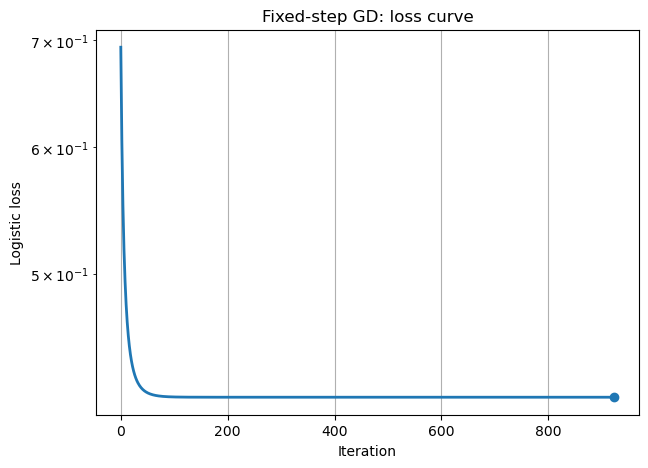

In [6]:
loss = res_gd_fixed["loss_history"]

plt.figure(figsize=(7, 5))
plt.plot(loss, linewidth=2)
plt.scatter(len(loss) - 1, loss[-1], zorder=3)
plt.xlabel("Iteration")
plt.ylabel("Logistic loss")
plt.title("Fixed-step GD: loss curve")
plt.yscale("log")
plt.grid(True)
plt.show()

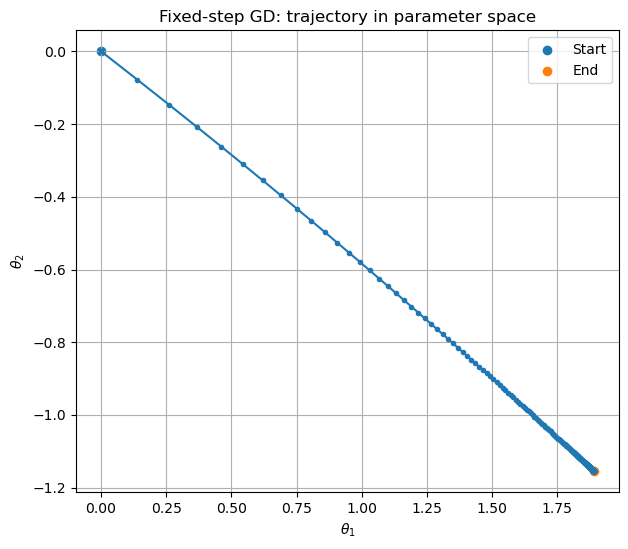

In [7]:
theta_hist = res_gd_fixed["theta_history"]

plt.figure(figsize=(7, 6))
plt.plot(theta_hist[:, 1], theta_hist[:, 2], marker="o", markersize=3, linewidth=1.5)
plt.scatter(theta_hist[0, 1], theta_hist[0, 2], label="Start")
plt.scatter(theta_hist[-1, 1], theta_hist[-1, 2], label="End")
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.title("Fixed-step GD: trajectory in parameter space")
plt.grid(True)
plt.legend()
plt.show()

# Part II. First-order method: Gradient Descent + Wolfe line search

We now replace the fixed step size by a line search.

At iteration $t$, let

$$
p_t = -\nabla f(\theta_t).
$$

We seek a step length $\gamma_t$ satisfying the **Wolfe conditions**:

$$
f(\theta_t + \gamma p_t)
\le
f(\theta_t) + c_1 \gamma \nabla f(\theta_t)^\top p_t
$$

and

$$
\nabla f(\theta_t + \gamma p_t)^\top p_t
\ge
c_2 \, \nabla f(\theta_t)^\top p_t,
\qquad 0 < c_1 < c_2 < 1.
$$

Below we use a simple backtracking-style routine: start from $\bar\gamma$, and repeatedly shrink by a factor $\rho$ until the Wolfe test is accepted.


In [8]:
def wolfe_backtracking_line_search(
    f,
    grad_f,
    theta,
    p,
    gamma_bar=1.0,
    rho=0.8,
    c1=1e-4,
    c2=0.9,
    max_backtracks=100,
):
    gamma = gamma_bar
    f0 = f(theta)
    g0 = grad_f(theta)
    directional0 = g0 @ p

    if directional0 >= 0:
        raise ValueError("Search direction is not a descent direction.")

    best_armijo = None

    for _ in range(max_backtracks):
        theta_new = theta + gamma * p
        f_new = f(theta_new)
        g_new = grad_f(theta_new)

        armijo_ok = f_new <= f0 + c1 * gamma * directional0
        curvature_ok = (g_new @ p) >= c2 * directional0

        if armijo_ok and best_armijo is None:
            best_armijo = (gamma, theta_new.copy(), f_new, g_new.copy())

        if armijo_ok and curvature_ok:
            return gamma, theta_new, f_new, g_new, True

        gamma *= rho

    if best_armijo is not None:
        gamma, theta_new, f_new, g_new = best_armijo
        return gamma, theta_new, f_new, g_new, False

    theta_new = theta + gamma * p
    f_new = f(theta_new)
    g_new = grad_f(theta_new)
    return gamma, theta_new, f_new, g_new, False


def logistic_gd_wolfe(
    X,
    y,
    gamma_bar=1.0,
    rho=0.8,
    c1=1e-4,
    c2=0.9,
    max_iter=500,
    tol=1e-10,
    fit_intercept=True,
):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    if fit_intercept:
        X = add_intercept(X)

    n, d = X.shape
    theta = np.zeros(d)

    def f_local(b):
        return logistic_loss(X, y, b)

    def grad_local(b):
        return logistic_gradient(X, y, b)

    loss_history = [f_local(theta)]
    theta_history = [theta.copy()]
    grad_norm_history = []
    step_history = []
    wolfe_hit_history = []

    for k in range(max_iter):
        grad = grad_local(theta)
        grad_norm = np.linalg.norm(grad)
        grad_norm_history.append(grad_norm)

        if grad_norm < tol:
            return {
                "theta": theta,
                "loss_history": np.array(loss_history),
                "theta_history": np.array(theta_history),
                "grad_norm_history": np.array(grad_norm_history),
                "step_history": np.array(step_history),
                "wolfe_hit_history": np.array(wolfe_hit_history),
                "n_iter": k,
            }

        p = -grad

        gamma, theta_new, f_new, grad_new, wolfe_hit = wolfe_backtracking_line_search(
            f=f_local,
            grad_f=grad_local,
            theta=theta,
            p=p,
            gamma_bar=gamma_bar,
            rho=rho,
            c1=c1,
            c2=c2,
            max_backtracks=100,
        )

        step_history.append(gamma)
        wolfe_hit_history.append(wolfe_hit)
        theta_history.append(theta_new.copy())
        loss_history.append(f_new)

        theta = theta_new

    return {
        "theta": theta,
        "loss_history": np.array(loss_history),
        "theta_history": np.array(theta_history),
        "grad_norm_history": np.array(grad_norm_history),
        "step_history": np.array(step_history),
        "wolfe_hit_history": np.array(wolfe_hit_history),
        "n_iter": max_iter,
    }


res_gd_wolfe = logistic_gd_wolfe(
    X, y,
    gamma_bar=1.0,
    rho=0.8,
    c1=1e-4,
    c2=0.9,
    max_iter=5000,
    tol=1e-10,
    fit_intercept=True,
)

print("Wolfe GD theta      :", res_gd_wolfe["theta"])
print("Wolfe GD iterations:", res_gd_wolfe["n_iter"])
print("First 10 accepted step sizes:", res_gd_wolfe["step_history"][:10])
print("Weak Wolfe satisfied on",
      int(np.sum(res_gd_wolfe["wolfe_hit_history"])),
      "iterations out of",
      len(res_gd_wolfe["wolfe_hit_history"]))

Wolfe GD theta      : [-0.50668317  1.89269678 -1.15491438]
Wolfe GD iterations: 5000
First 10 accepted step sizes: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Weak Wolfe satisfied on 10 iterations out of 5000


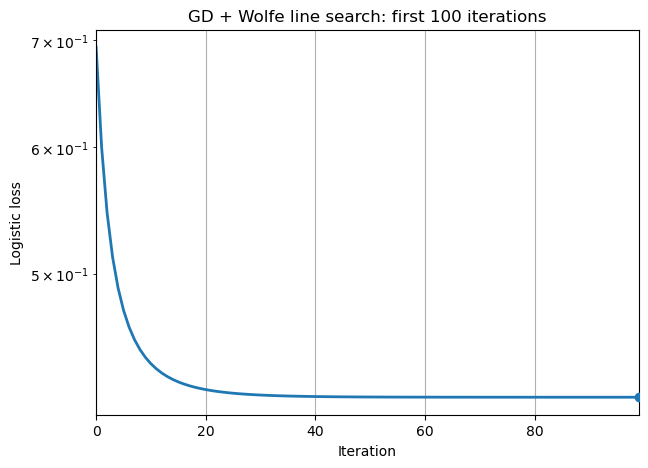

In [9]:
loss = res_gd_wolfe["loss_history"]
m = 100

plt.figure(figsize=(7, 5))
plt.plot(loss[:m], linewidth=2)
plt.scatter(m - 1, loss[m - 1], zorder=3)
plt.xlabel("Iteration")
plt.ylabel("Logistic loss")
plt.title("GD + Wolfe line search: first 100 iterations")
plt.yscale("log")
plt.xlim(0, m - 1)
plt.grid(True)
plt.show()

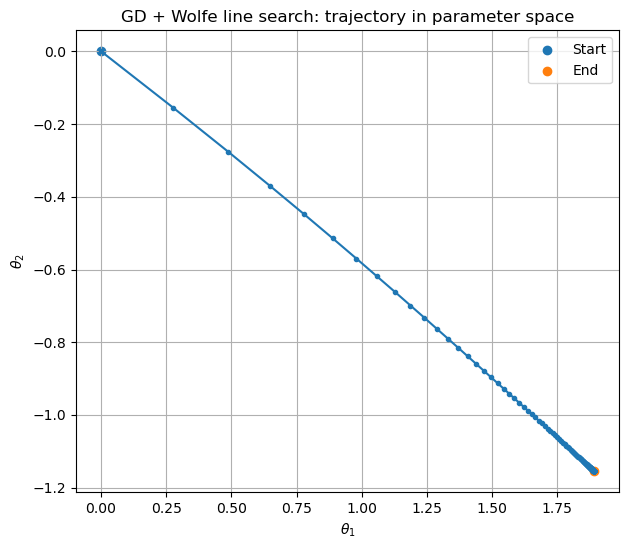

In [10]:
theta_hist = res_gd_wolfe["theta_history"]

plt.figure(figsize=(7, 6))
plt.plot(theta_hist[:, 1], theta_hist[:, 2], marker="o", markersize=3, linewidth=1.5)
plt.scatter(theta_hist[0, 1], theta_hist[0, 2], label="Start")
plt.scatter(theta_hist[-1, 1], theta_hist[-1, 2], label="End")
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.title("GD + Wolfe line search: trajectory in parameter space")
plt.grid(True)
plt.legend()
plt.show()

# Part III. Newton's method

For logistic regression, Newton's method uses

$$
\theta_{t+1}
=
\theta_t - H(\theta_t)^{-1} \nabla f(\theta_t),
$$

where $H(\theta_t)$ is the Hessian of the logistic loss.

Since the Hessian changes with $\theta$, Newton's method is no longer a one-step exact solver as in OLS, but it usually converges much faster than first-order methods.


In [11]:
def logistic_newton(X, y, max_iter=100, tol=1e-10, fit_intercept=True, damping=1e-6):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    if fit_intercept:
        X = add_intercept(X)

    n, d = X.shape
    theta = np.zeros(d)

    loss_history = [logistic_loss(X, y, theta)]
    theta_history = [theta.copy()]
    grad_norm_history = []

    for k in range(max_iter):
        grad = logistic_gradient(X, y, theta)
        grad_norm_history.append(np.linalg.norm(grad))

        H = logistic_hessian(X, theta) + damping * np.eye(d)
        step = np.linalg.solve(H, grad)
        theta_new = theta - step

        theta_history.append(theta_new.copy())
        loss_history.append(logistic_loss(X, y, theta_new))

        if np.linalg.norm(theta_new - theta) < tol:
            theta = theta_new
            return {
                "theta": theta,
                "loss_history": np.array(loss_history),
                "theta_history": np.array(theta_history),
                "grad_norm_history": np.array(grad_norm_history),
                "n_iter": k + 1,
            }

        theta = theta_new

    return {
        "theta": theta,
        "loss_history": np.array(loss_history),
        "theta_history": np.array(theta_history),
        "grad_norm_history": np.array(grad_norm_history),
        "n_iter": max_iter,
    }


res_nt = logistic_newton(X, y, max_iter=50, tol=1e-12, fit_intercept=True, damping=1e-6)

print("Newton theta      :", res_nt["theta"])
print("Newton iterations:", res_nt["n_iter"])

Newton theta      : [-0.5066832   1.89269687 -1.15491444]
Newton iterations: 8


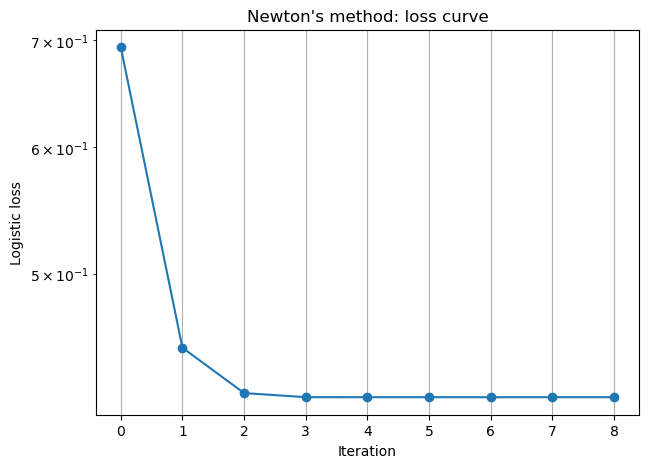

In [12]:
plt.figure(figsize=(7, 5))
plt.plot(res_nt["loss_history"], marker="o")
plt.xlabel("Iteration")
plt.ylabel("Logistic loss")
plt.title("Newton's method: loss curve")
plt.yscale("log")
plt.grid(True)
plt.show()

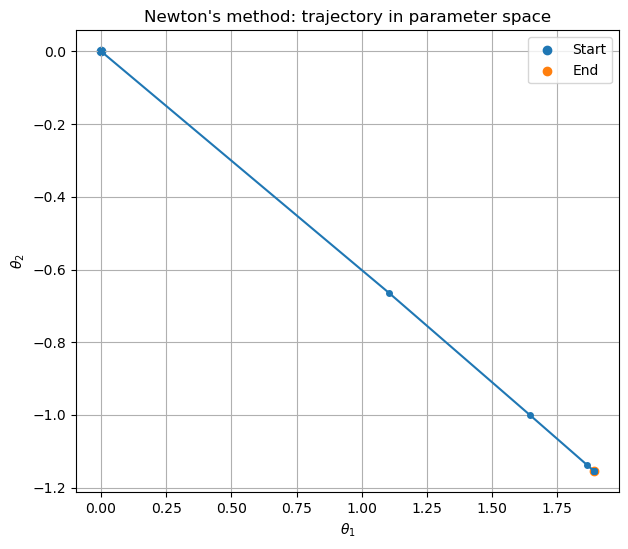

In [13]:
theta_hist = res_nt["theta_history"]

plt.figure(figsize=(7, 6))
plt.plot(theta_hist[:, 1], theta_hist[:, 2], marker="o", markersize=4, linewidth=1.5)
plt.scatter(theta_hist[0, 1], theta_hist[0, 2], label="Start")
plt.scatter(theta_hist[-1, 1], theta_hist[-1, 2], label="End")
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.title("Newton's method: trajectory in parameter space")
plt.grid(True)
plt.legend()
plt.show()

# Part IV. scikit-learn reference solution

Finally, we fit the same problem using `scikit-learn` as a reference implementation.


In [14]:
clf = LogisticRegression(
    penalty=None,
    fit_intercept=False,
    solver="lbfgs",
    max_iter=10000,
)
clf.fit(add_intercept(X), y)

theta_sklearn = clf.coef_.reshape(-1)

print("scikit-learn theta:", theta_sklearn)

scikit-learn theta: [-0.5067106   1.89271908 -1.15494139]


d:\miniconda3\envs\py311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## Final comparison

In [15]:
print("True theta             :", theta_true)
print("Fixed-step GD theta    :", res_gd_fixed["theta"])
print("Wolfe GD theta         :", res_gd_wolfe["theta"])
print("Newton theta           :", res_nt["theta"])
print("scikit-learn theta     :", theta_sklearn)

print()
summarize_classifier("Fixed-step GD", res_gd_fixed["theta"], X, y)
summarize_classifier("Wolfe GD",      res_gd_wolfe["theta"], X, y)
summarize_classifier("Newton",        res_nt["theta"], X, y)
summarize_classifier("scikit-learn",  theta_sklearn, X, y)

print()
print("Final gradient norms")
print("Fixed-step GD grad norm :", np.linalg.norm(logistic_gradient(add_intercept(X), y, res_gd_fixed["theta"])))
print("Wolfe GD grad norm      :", np.linalg.norm(logistic_gradient(add_intercept(X), y, res_gd_wolfe["theta"])))
print("Newton grad norm        :", np.linalg.norm(logistic_gradient(add_intercept(X), y, res_nt["theta"])))

True theta             : [-0.3  2.  -1.5]
Fixed-step GD theta    : [-0.5066832   1.89269687 -1.15491444]
Wolfe GD theta         : [-0.50668317  1.89269678 -1.15491438]
Newton theta           : [-0.5066832   1.89269687 -1.15491444]
scikit-learn theta     : [-0.5067106   1.89271908 -1.15494139]

Fixed-step GD        accuracy = 0.8000, log-loss = 0.418757
Wolfe GD             accuracy = 0.8000, log-loss = 0.418757
Newton               accuracy = 0.8000, log-loss = 0.418757
scikit-learn         accuracy = 0.8000, log-loss = 0.418757

Final gradient norms
Fixed-step GD grad norm : 1.9134451892271783e-12
Wolfe GD grad norm      : 5.758312122068628e-09
Newton grad norm        : 1.2296722415575151e-17


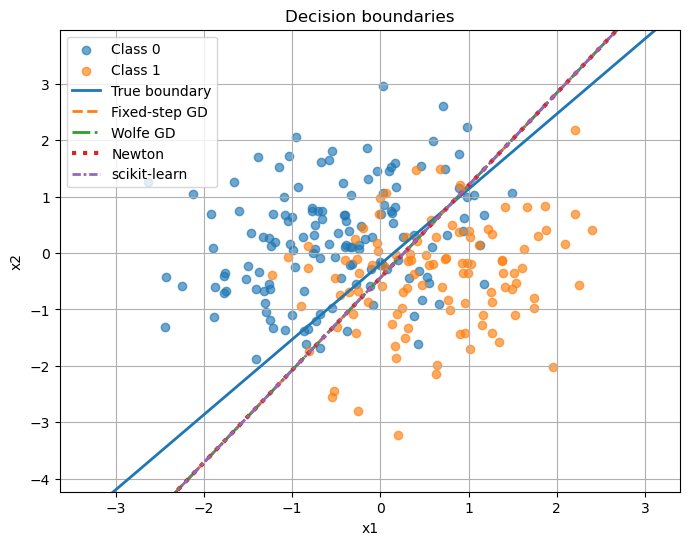

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], alpha=0.65, label="Class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], alpha=0.65, label="Class 1")

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1

plot_boundary(theta_true, x_min, x_max, label="True boundary", linestyle="-", linewidth=2)
plot_boundary(res_gd_fixed["theta"], x_min, x_max, label="Fixed-step GD", linestyle="--", linewidth=2)
plot_boundary(res_gd_wolfe["theta"], x_min, x_max, label="Wolfe GD", linestyle="-.", linewidth=2)
plot_boundary(res_nt["theta"], x_min, x_max, label="Newton", linestyle=":", linewidth=3)
plot_boundary(theta_sklearn, x_min, x_max, label="scikit-learn", linestyle=(0, (3, 1, 1, 1)), linewidth=2)

plt.xlim(x_min, x_max)
plt.ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision boundaries")
plt.legend()
plt.grid(True)
plt.show()

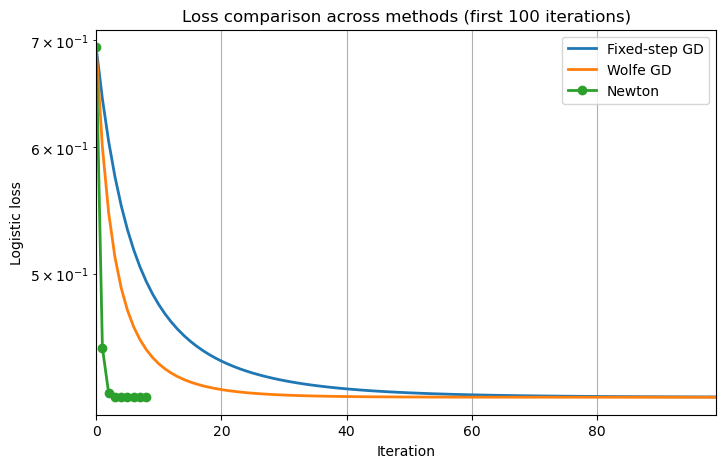

In [ ]:
m = 100

plt.figure(figsize=(8, 5))
plt.plot(res_gd_fixed["loss_history"][:m], label="Fixed-step GD", linewidth=2)
plt.plot(res_gd_wolfe["loss_history"][:m], label="Wolfe GD", linewidth=2)
# plt.plot(res_nt["loss_history"][:m], label="Newton", linewidth=2, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Logistic loss")
plt.title("Loss comparison across methods (first 100 iterations)")
plt.yscale("log")
plt.xlim(0, m - 1)
plt.grid(True)
plt.legend()
plt.show()

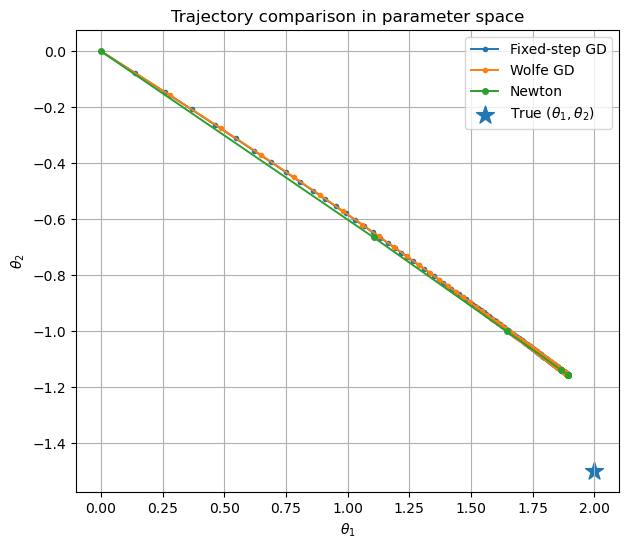

In [18]:
plt.figure(figsize=(7, 6))
plt.plot(res_gd_fixed["theta_history"][:, 1], res_gd_fixed["theta_history"][:, 2],
         marker="o", markersize=3, linewidth=1.4, label="Fixed-step GD")
plt.plot(res_gd_wolfe["theta_history"][:, 1], res_gd_wolfe["theta_history"][:, 2],
         marker="o", markersize=3, linewidth=1.4, label="Wolfe GD")
plt.plot(res_nt["theta_history"][:, 1], res_nt["theta_history"][:, 2],
         marker="o", markersize=4, linewidth=1.4, label="Newton")

plt.scatter(theta_true[1], theta_true[2], marker="*", s=180, label=r"True $(\theta_1,\theta_2)$")
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.title("Trajectory comparison in parameter space")
plt.grid(True)
plt.legend()
plt.show()

## Summary

- **Fixed-step GD** is the most direct first-order baseline, but its speed depends heavily on the chosen learning rate.
- **GD + Wolfe line search** adapts the step size automatically and is usually more robust than a manually fixed step.
- **Newton's method** uses curvature information, so it typically converges in many fewer iterations.
- **scikit-learn** provides a convenient optimized reference implementation.
